# Customer Segmentation Analysis

## Project Objective
The goal of this project is to analyze customer demographics and spending behavior to identify distinct customer segments.

Understanding these segments can help businesses:
- target marketing campaigns
- improve customer retention
- increase overall revenue



## Dataset Description

The dataset contains information about mall customers including:

- CustomerID : Unique ID assigned to the customer
- Gender : Male / Female
- Age : Age of the customer
- Annual Income (k$) : Annual income of the customer
- Spending Score (1–100) : Score assigned based on customer spending behavior

The dataset will be used to explore customer demographics and identify spending patterns.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

print("Libraries imported successfully")

Libraries imported successfully


## Load Dataset

In [9]:
df = pd.read_csv("../data/Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Dataset Shape
This shows the number of rows and columns in the dataset.

In [10]:
df.shape

(200, 5)

## Dataset Information
This step helps us understand the structure of the dataset including data types and missing values.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


## Statistical Summary
This provides descriptive statistics for numerical columns such as mean, minimum, maximum and quartiles.

In [12]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Checking Missing Values

In [14]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

## Renaming Columns for Easier Analysis

In [15]:
df.rename(columns={
    'Annual Income (k$)': 'Annual_Income',
    'Spending Score (1-100)': 'Spending_Score'
}, inplace=True)

df.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Age Distribution of Customers
This visualization helps us understand the age demographics of mall customers.

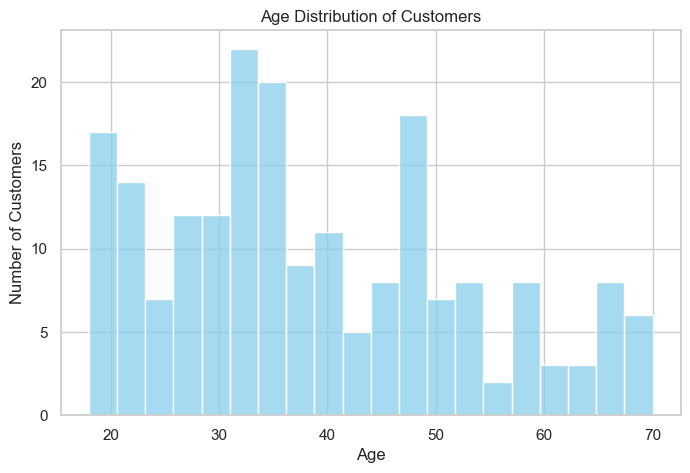

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20, color='skyblue')

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.savefig("../visuals/age_distribution.png")

plt.show()

## Gender Distribution
This chart shows how customers are distributed by gender.

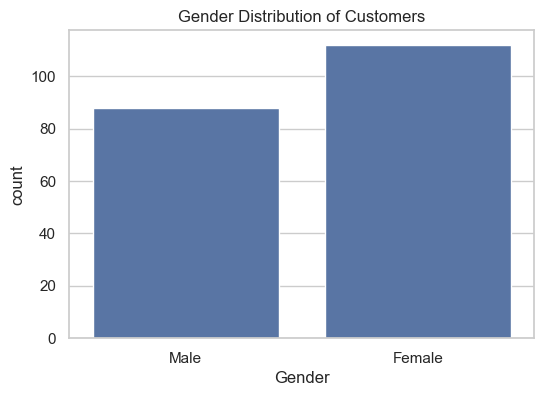

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(x='Gender', data=df)

plt.title("Gender Distribution of Customers")

plt.savefig("../visuals/gender_distribution.png")

plt.show()

## Annual Income Distribution
Understanding income distribution helps identify purchasing power among customers.

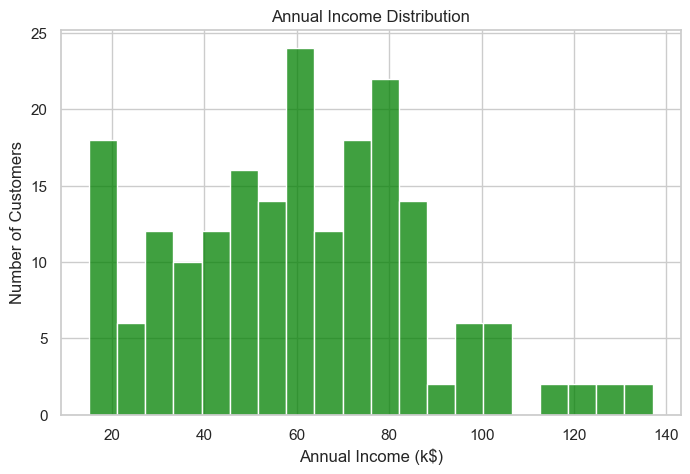

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df['Annual_Income'], bins=20, color='green')

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Number of Customers")

plt.savefig("../visuals/income_distribution.png")

plt.show()

## Spending Score Distribution
Spending score indicates how actively customers spend money at the mall.

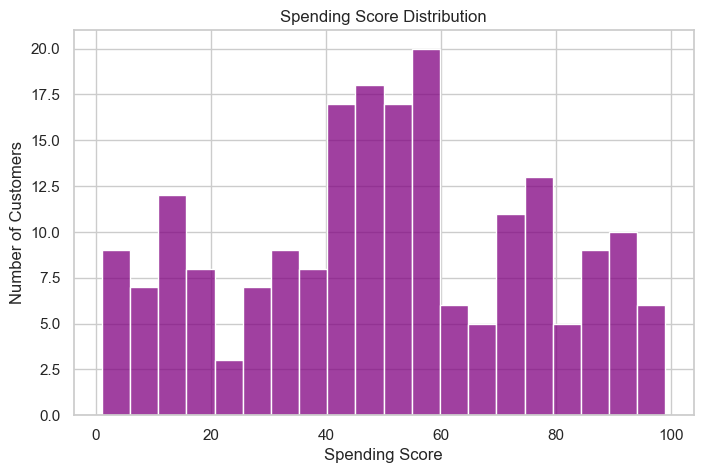

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(df['Spending_Score'], bins=20, color='purple')

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Number of Customers")

plt.savefig("../visuals/spending_distribution.png")

plt.show()

## Income vs Spending Score

This scatter plot helps identify relationships between income levels and spending behavior.

## Income vs Spending Score

This scatter plot helps identify relationships between income levels and spending behavior.

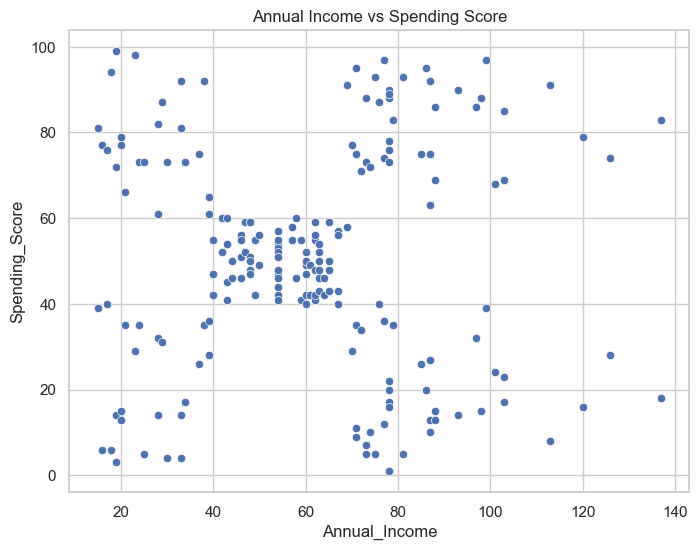

In [20]:
plt.figure(figsize=(8,6))

sns.scatterplot(x='Annual_Income', y='Spending_Score', data=df)

plt.title("Annual Income vs Spending Score")

plt.savefig("../visuals/income_vs_spending.png")

plt.show()

## Age vs Spending Score
This visualization helps identify how spending patterns vary with age.

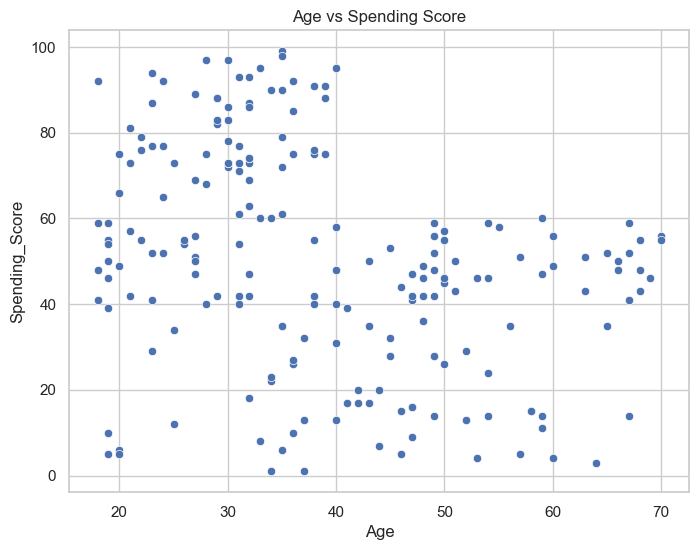

In [21]:
plt.figure(figsize=(8,6))

sns.scatterplot(x='Age', y='Spending_Score', data=df)

plt.title("Age vs Spending Score")

plt.savefig("../visuals/age_vs_spending.png")

plt.show()

## Average Spending by Gender
This analysis compares spending behavior between male and female customers.

In [22]:
df.groupby('Gender')['Spending_Score'].mean()

Gender
Female    51.526786
Male      48.511364
Name: Spending_Score, dtype: float64

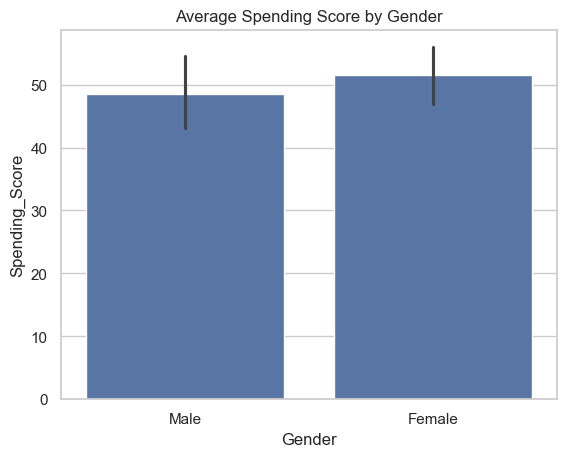

In [23]:
#visualizaion

sns.barplot(x='Gender', y='Spending_Score', data=df)

plt.title("Average Spending Score by Gender")

plt.savefig("../visuals/spending_by_gender.png")

plt.show()

## Summary of Findings
## Key Insights

1. The majority of customers fall within the **20–40 age range**, indicating that younger and middle-aged individuals represent a significant portion of the mall’s customer base.

2. The **annual income distribution** shows a wide spread of customer purchasing power, suggesting the mall attracts both moderate-income and high-income shoppers.

3. Analysis of **spending scores** reveals notable variation in customer spending behavior, indicating that not all high-income customers are necessarily high spenders.

4. The **Income vs Spending Score visualization** reveals distinct patterns that suggest the presence of different customer groups with varying spending behaviors.

5. Some customers with **high income but low spending scores** represent a potential opportunity for targeted marketing campaigns aimed at increasing their engagement and purchases.

6. Conversely, **high-income high-spending customers** appear to represent a valuable customer segment that businesses could prioritize through loyalty programs or premium offerings.

## Customer Segmentation using K-Means Clustering

To better understand customer behavior, we will use **K-Means clustering**, an unsupervised machine learning algorithm.

K-Means groups customers based on similarities in their features. In this case, we will use:

- Annual Income
- Spending Score

This helps identify distinct customer segments that businesses can target with different marketing strategies.

In [24]:
from sklearn.cluster import KMeans

## Feature Selection

For segmentation, we will use the following features:

- Annual Income
- Spending Score

These variables capture customer purchasing power and spending behavior.

In [25]:
X = df[['Annual_Income', 'Spending_Score']]

## Determining the Optimal Number of Clusters

The Elbow Method helps determine the optimal number of clusters by measuring how well the data fits within each cluster.

The goal is to find a point where adding more clusters does not significantly improve the model.

In [26]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

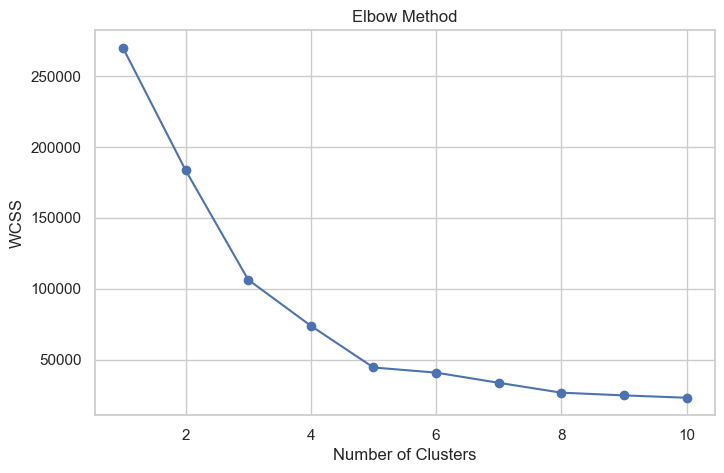

In [27]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.savefig("../visuals/elbow_method.png")

plt.show()

## Applying K-Means Clustering

Based on the elbow method, we will use **5 clusters** to segment customers.

In [28]:
kmeans = KMeans(n_clusters=5, random_state=42)

df['Cluster'] = kmeans.fit_predict(X)

In [29]:
df.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score,Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


## Customer Segments Visualization

This visualization shows how customers are grouped based on income and spending behavior.

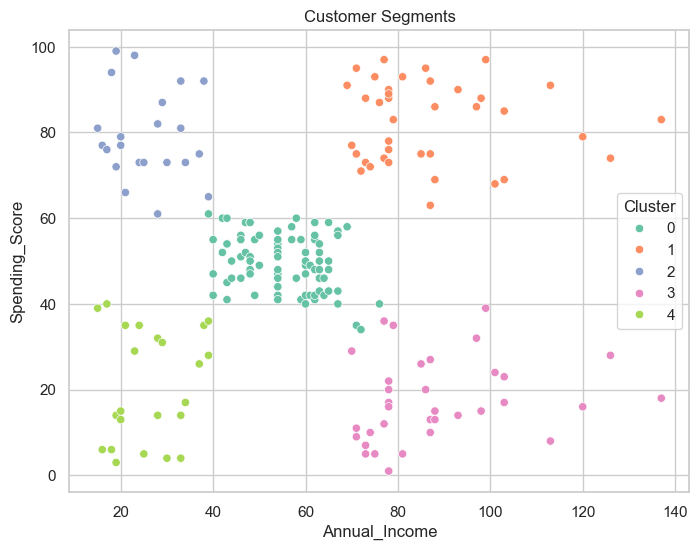

In [30]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Annual_Income',
    y='Spending_Score',
    hue='Cluster',
    palette='Set2',
    data=df
)

plt.title("Customer Segments")

plt.savefig("../visuals/customer_segments.png")

plt.show()

## Interpretation of Customer Segments

Cluster analysis reveals distinct groups of customers:

Cluster 0:
Customers with moderate income and moderate spending behavior.

Cluster 1:
High-income customers with high spending scores — likely the most valuable customers.

Cluster 2:
Customers with lower income but relatively high spending behavior.

Cluster 3:
High-income customers with low spending scores — potential targets for marketing campaigns.

Cluster 4:
Customers with lower income and lower spending patterns.

## Business Recommendations

Based on the identified customer segments, businesses can adopt targeted strategies:

1. High-income high-spending customers should be prioritized through loyalty programs and exclusive offers.

2. High-income low-spending customers represent a key opportunity for marketing campaigns aimed at increasing engagement.

3. Customers with moderate income and moderate spending could benefit from personalized promotions.

4. Low-income low-spending segments may respond better to discounts and seasonal sales.